# Multi-Agent Workflows + RAG - LangGraph



# Session 6 — Multi-Agent Apps with LangGraph: Concepts, Code & Prep

## Concepts Overview (what & why)

Multi-agent systems decompose an application into **specialized LLM-powered actors** (agents) that collaborate via an explicit **graph**. Each agent has a role, optional tools, and a shared **state**—and a **supervisor** routes work to the right agent. This is the same building block as single-agent apps, just **more of it**: more nodes, clearer boundaries, and tighter control over flow.

In this session we build a **hierarchical design** with three layers:

* **Research Team**: a searcher (live web via Tavily) and a RAG retriever over a local corpus; a team-level **supervisor** chooses who acts next.
* **Document Team**: writer, note-taker, copy-editor; each owns simple file tools; a team-level **supervisor** manages drafting → editing loops.
* **Meta-Supervisor**: sits above both teams and decides whether the next step is **research** or **response writing**.

Why this structure works:

* **Separation of concerns** → simpler prompts, targeted tools, easier debugging.
* **Routing vs. Planning** → the supervisor is an *LLM router* (function-calling) that selects the next node; you keep control of edges, recursion depth, and termination (FINISH).
* **Piecewise optimization** → swap a tool/model per node, capture traces per edge, and evaluate locally before scaling.
* **Production considerations**: choose cost-efficient models for “heavy traffic” nodes (e.g., writer/copy-editor) and stronger reasoning where routing quality limits outcomes (supervisors). Add **observability hooks** around tool calls and supervisor decisions; bound **recursion_limit** to avoid runaway loops; prefer **deterministic prompts** and constants.

Key patterns & trade-offs:

* **Tools vs Agents**: a tool can be wrapped as a single-tool agent; an agent can expose tools. Favor the simplest abstraction that fits the flow.
* **RAG locality**: keep the retriever **in-memory** for demos, swap to Qdrant/Postgres for persistence and scale; keep **embedding model** & **splitters** configurable constants.
* **State shape** matters: messages, next, and team_members are minimal but sufficient for routing and streaming. Add fields (e.g., artifacts) only when necessary.
* **Safety rails**: supervisors restrict scope (“research-only” vs “authoring”), preventing capability creep and reducing hallucinations.

## Code Breakdown (how it fits)

**RAG building block (single-agent node)**

* Load & split PDFs; embed with `text-embedding-3-small`; index with **Qdrant (in-memory)**; expose a retriever.
* **LCEL chain**: `ChatPromptTemplate` → `ChatOpenAI` → `StrOutputParser`.
* Wrapped as a LangGraph sequence: `retrieve → generate`, compiled to `compiled_rag_graph`.
  *Snippet*

  ```python
  class State(TypedDict):
      question: str; context: List[Document]; response: str

  def retrieve(s:State): return {"context": qdrant_retriever.invoke(s["question"])}
  def generate(s:State): return {"response": (chat_prompt | llm | StrOutputParser()).invoke(
      {"query": s["question"], "context": s["context"]})}
  ```

**Reusable helpers (glue for agents)**

* `create_agent(llm, tools, system)` → function-calling **AgentExecutor** with a standard suffix (autonomy, no clarification).
* `agent_node(state, agent, name)` → adapts an agent to a **LangGraph node** (returns a `HumanMessage` with the agent’s output).
* `create_team_supervisor(llm, system, members)` → **router** via function-calling schema `{next: enum(members + FINISH)}`.

**Research Team graph**

* Tools: `TavilySearchResults`, `retrieve_information` (calls `compiled_rag_graph`).
* Agents/Nodes: `Search`, `HowPeopleUseAIRetriever`.
* Supervisor: `ResearchSupervisor` routes among the two and FINISH.
* Entry at supervisor; agent nodes **loop back** to supervisor; `research_chain` wraps the compiled graph for easy streaming.

**Document Team graph**

* File tools: `create_outline`, `write_document`, `read_document`, `edit_document`; plus `reference_previous_responses` (vector search over cohort CSV).
* `prelude(state)` injects **current_files** context so writing agents are state-aware.
* Agents/Nodes: `DocWriter`, `NoteTaker`, `CopyEditor`; Supervisor: `AuthoringSupervisor`.
* Same edge pattern: agent → supervisor; supervisor conditional routes; compiled & wrapped as `authoring_chain`.

**Meta-Supervisor (whole system)**

* State has just `messages` and `next`.
* Two nodes are **entire subgraphs**: `"Research team"` runs `research_chain`, `"Response team"` runs `authoring_chain`.
* `get_last_message` passes only the latest parent message down; `join_graph` lifts the subgraph’s last message up.
* `SuperSupervisor` routes between teams and FINISH. Stream with bounded recursion.

**Best-practice nits to watch in class**

* Keep **constants** for model names, chunking, embeddings, and prompts.
* Prefer **distinct function names** (avoid reusing `enter_chain` with different signatures).
* Add **tracing/eval hooks** around: supervisor decisions, tool invocations, and final outputs.

## Pre-Class Prep Tips (advanced)

* Run the notebook twice: once with **gpt-4o-mini** everywhere; once with a stronger model only for supervisors. Compare routing quality, tool choice, and cost.
* Swap retriever: test **BM25** (or in-memory FAISS) vs Qdrant; measure hits/latency under 25–50 queries (batch).
* Force routes: temporarily **disable** one agent per team and confirm the supervisor degrades gracefully; then re-enable and compare traces.
* Add **guardrails**: cap recursion per subgraph; add a “max tool calls” guard; log when FINISH isn’t reached within N steps.
* Inject **edge cases**: empty corpus, bad PDF, missing file names in `edit_document`; verify supervisors still FINISH and errors don’t leak into messages.


In [1]:
import os
import getpass

os.environ["OPENAI_API_KEY"] = getpass.getpass("OpenAI API Key:")
os.environ["TAVILY_API_KEY"] = getpass.getpass("TAVILY_API_KEY")

In [2]:
from langchain_community.document_loaders import DirectoryLoader
from langchain_community.document_loaders import PyMuPDFLoader

directory_loader = DirectoryLoader("data", glob="**/*.pdf", loader_cls=PyMuPDFLoader)

how_people_use_ai_documents = directory_loader.load()

In [3]:
import tiktoken
from langchain.text_splitter import RecursiveCharacterTextSplitter

def tiktoken_len(text):
    tokens = tiktoken.encoding_for_model("gpt-4o").encode(
        text,
    )
    return len(tokens)

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size = 750,
    chunk_overlap = 0,
    length_function = tiktoken_len,
)

how_people_use_ai_chunks = text_splitter.split_documents(how_people_use_ai_documents)

In [4]:
len(how_people_use_ai_chunks)

71

In [5]:
from langchain_openai.embeddings import OpenAIEmbeddings

embedding_model = OpenAIEmbeddings(model="text-embedding-3-small")

In [6]:
from langchain_community.vectorstores import Qdrant

qdrant_vectorstore = Qdrant.from_documents(
    documents=how_people_use_ai_chunks,
    embedding=embedding_model,
    location=":memory:"
)

In [7]:
qdrant_retriever = qdrant_vectorstore.as_retriever()

In [8]:
from langchain_core.prompts import ChatPromptTemplate

HUMAN_TEMPLATE = """
#CONTEXT:
{context}

QUERY:
{query}

Use the provide context to answer the provided user query. Only use the provided context to answer the query. If you do not know the answer, or it's not contained in the provided context respond with "I don't know"
"""

chat_prompt = ChatPromptTemplate.from_messages([
    ("human", HUMAN_TEMPLATE)
])

In [9]:
from langchain_openai import ChatOpenAI

generator_llm = ChatOpenAI(model="gpt-4.1-nano")

In [10]:
from langgraph.graph import START, StateGraph
from typing_extensions import List, TypedDict
from langchain_core.documents import Document
from langchain_core.output_parsers import StrOutputParser

class State(TypedDict):
  question: str
  context: List[Document]
  response: str

def retrieve(state: State):
  retrieved_docs = qdrant_retriever.invoke(state["question"])
  return {"context" : retrieved_docs}

def generate(state: State):
  generator_chain = chat_prompt | generator_llm | StrOutputParser()
  response = generator_chain.invoke({"query" : state["question"], "context" : state["context"]})
  return {"response" : response}

rag_graph = StateGraph(State).add_sequence([retrieve, generate])
rag_graph.add_edge(START, "retrieve")
compiled_rag_graph = rag_graph.compile()

In [11]:
compiled_rag_graph.invoke({"question" : "How does the average person use AI?"})

{'question': 'How does the average person use AI?',
 'context': [Document(metadata={'producer': 'macOS Version 15.4.1 (Build 24E263) Quartz PDFContext, AppendMode 1.1', 'creator': 'LaTeX with hyperref', 'creationdate': '2025-09-12T20:05:32+00:00', 'source': 'data/howpeopleuseai.pdf', 'file_path': 'data/howpeopleuseai.pdf', 'total_pages': 64, 'format': 'PDF 1.6', 'title': 'How People Use ChatGPT', 'author': '', 'subject': '', 'keywords': '', 'moddate': '2025-09-15T10:32:36-04:00', 'trapped': '', 'modDate': "D:20250915103236-04'00'", 'creationDate': 'D:20250912200532Z', 'page': 17, '_id': '0c06be7c87b940bdaa45f4b9fb29a828', '_collection_name': 'c52471fe3f2a4d3f962097462c2ffdd8'}, page_content='suggests that most user Writing conversations with ChatGPT are requests to modify user inputs\nrather than to create something new. Education is a major use case for ChatGPT. 10.2% of all user\nmessages and 36% of Practical Guidance messages are requests for Tutoring or Teaching. Another\nlarge sha

In [12]:
from typing import Any, Callable, List, Optional, TypedDict, Union

from langchain.agents import AgentExecutor, create_openai_functions_agent
from langchain.output_parsers.openai_functions import JsonOutputFunctionsParser
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain_core.messages import AIMessage, BaseMessage, HumanMessage
from langchain_core.runnables import Runnable
from langchain_core.tools import BaseTool
from langchain_openai import ChatOpenAI

from langgraph.graph import END, StateGraph

In [13]:
def agent_node(state, agent, name):
    result = agent.invoke(state)
    return {"messages": [HumanMessage(content=result["output"], name=name)]}

In [14]:
def create_agent(
    llm: ChatOpenAI,
    tools: list,
    system_prompt: str,
) -> str:
    """Create a function-calling agent and add it to the graph."""
    system_prompt += ("\nWork autonomously according to your specialty, using the tools available to you."
    " Do not ask for clarification."
    " Your other team members (and other teams) will collaborate with you with their own specialties."
    " You are chosen for a reason!")
    prompt = ChatPromptTemplate.from_messages(
        [
            (
                "system",
                system_prompt,
            ),
            MessagesPlaceholder(variable_name="messages"),
            MessagesPlaceholder(variable_name="agent_scratchpad"),
        ]
    )
    agent = create_openai_functions_agent(llm, tools, prompt)
    executor = AgentExecutor(agent=agent, tools=tools)
    return executor

In [15]:
def create_team_supervisor(llm: ChatOpenAI, system_prompt, members) -> str:
    """An LLM-based router."""
    options = ["FINISH"] + members
    function_def = {
        "name": "route",
        "description": "Select the next role.",
        "parameters": {
            "title": "routeSchema",
            "type": "object",
            "properties": {
                "next": {
                    "title": "Next",
                    "anyOf": [
                        {"enum": options},
                    ],
                },
            },
            "required": ["next"],
        },
    }
    prompt = ChatPromptTemplate.from_messages(
        [
            ("system", system_prompt),
            MessagesPlaceholder(variable_name="messages"),
            (
                "system",
                "Given the conversation above, who should act next?"
                " Or should we FINISH? Select one of: {options}",
            ),
        ]
    ).partial(options=str(options), team_members=", ".join(members))
    return (
        prompt
        | llm.bind_functions(functions=[function_def], function_call="route")
        | JsonOutputFunctionsParser()
    )

In [16]:
from langchain_community.tools.tavily_search import TavilySearchResults

tavily_tool = TavilySearchResults(max_results=5)

/tmp/ipykernel_85754/1911882425.py:3: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-tavily package and should be used instead. To use it run `pip install -U :class:`~langchain-tavily` and import as `from :class:`~langchain_tavily import TavilySearch``.
  tavily_tool = TavilySearchResults(max_results=5)


In [17]:
from typing import Annotated, List, Tuple, Union
from langchain_core.tools import tool

@tool
def retrieve_information(
    query: Annotated[str, "query to ask the retrieve information tool"]
    ):
  """Use Retrieval Augmented Generation to retrieve information about how people use AI"""
  return compiled_rag_graph.invoke({"question" : query})

In [18]:
import functools
import operator

from langchain_core.messages import AIMessage, BaseMessage, HumanMessage
from langchain_openai.chat_models import ChatOpenAI
import functools

class ResearchTeamState(TypedDict):
    messages: Annotated[List[BaseMessage], operator.add]
    team_members: List[str]
    next: str

In [19]:
research_llm = ChatOpenAI(model="gpt-4o-mini")

In [20]:
search_agent = create_agent(
    research_llm,
    [tavily_tool],
    "You are a research assistant who can search for up-to-date info using the tavily search engine.",
)
search_node = functools.partial(agent_node, agent=search_agent, name="Search")

In [21]:
research_agent = create_agent(
    research_llm,
    [retrieve_information],
    "You are a research assistant who can provide specific information on how people use AI",
)
research_node = functools.partial(agent_node, agent=research_agent, name="HowPeopleUseAIRetriever")

In [22]:
research_supervisor_agent = create_team_supervisor(
    research_llm,
    ("You are a supervisor tasked with managing a conversation between the"
    " following workers:  Search, HowPeopleUseAIRetriever. Given the following user request,"
    " determine the subject to be researched and respond with the worker to act next. Each worker will perform a"
    " task and respond with their results and status. "
    " You should never ask your team to do anything beyond research. They are not required to write content or posts."
    " You should only pass tasks to workers that are specifically research focused."
    " When finished, respond with FINISH."),
    ["Search", "HowPeopleUseAIRetriever"],
)

/tmp/ipykernel_85754/488856706.py:34: LangChainDeprecationWarning: The method `BaseChatOpenAI.bind_functions` was deprecated in langchain-openai 0.2.1 and will be removed in 1.0.0. Use :meth:`~langchain_openai.chat_models.base.ChatOpenAI.bind_tools` instead.
  | llm.bind_functions(functions=[function_def], function_call="route")


In [23]:
research_graph = StateGraph(ResearchTeamState)

research_graph.add_node("Search", search_node)
research_graph.add_node("HowPeopleUseAIRetriever", research_node)
research_graph.add_node("ResearchSupervisor", research_supervisor_agent)

In [24]:
research_graph.add_edge("Search", "ResearchSupervisor") 
research_graph.add_edge("HowPeopleUseAIRetriever", "ResearchSupervisor")
research_graph.add_conditional_edges(
    "ResearchSupervisor",
    lambda x: x["next"],
    {"Search": "Search", "HowPeopleUseAIRetriever": "HowPeopleUseAIRetriever", "FINISH": END},
)
research_graph.set_entry_point("ResearchSupervisor")

In [25]:
compiled_research_graph = research_graph.compile()

In [26]:
import nest_asyncio
nest_asyncio.apply()

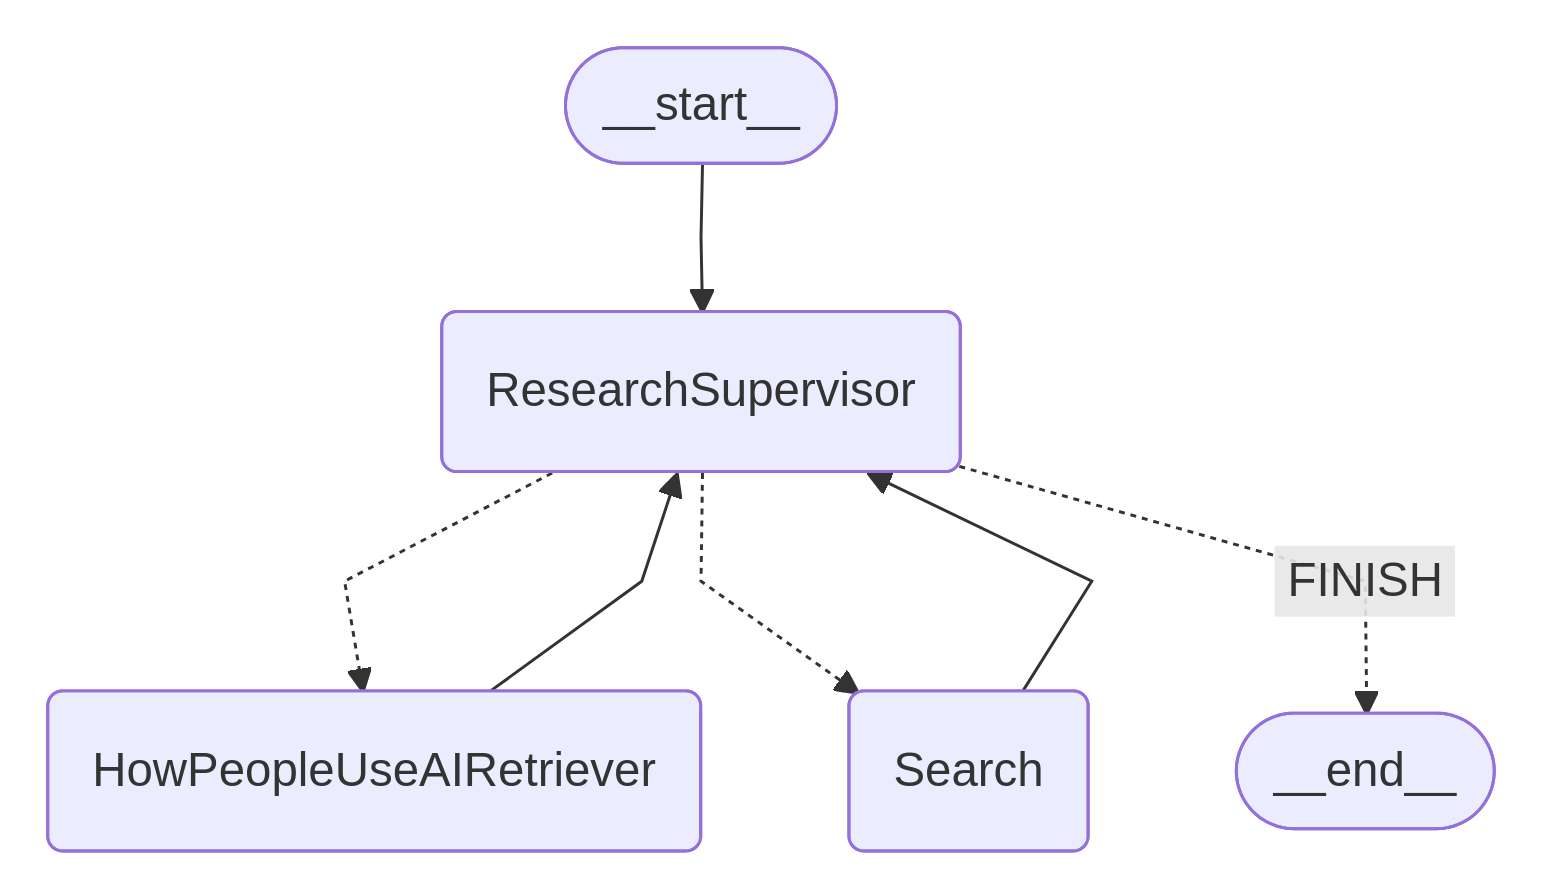

In [27]:
from IPython.display import Image, display
from langchain_core.runnables.graph import CurveStyle, MermaidDrawMethod, NodeStyles

display(
    Image(
        compiled_research_graph.get_graph().draw_mermaid_png(
            curve_style=CurveStyle.LINEAR,
            node_colors=NodeStyles(first="#ffdfba", last="#baffc9", default="#fad7de"),
            wrap_label_n_words=9,
            output_file_path=None,
            draw_method=MermaidDrawMethod.PYPPETEER,
            background_color="white",
            padding=10,
        )
    )
)

In [28]:
def enter_research_chain(message: str):
    results = {
        "messages": [HumanMessage(content=message)],
    }
    return results

research_chain = enter_research_chain | compiled_research_graph

In [29]:
for s in research_chain.stream(
    "How are people using AI to improve their lives?", {"recursion_limit": 100}
):
    if "__end__" not in s:
        print(s)
        print("---")

{'ResearchSupervisor': {'next': 'HowPeopleUseAIRetriever'}}
---
{'HowPeopleUseAIRetriever': {'messages': [HumanMessage(content="People are using AI, specifically tools like ChatGPT, to improve their lives in various meaningful ways:\n\n1. **Education**: A significant number of users leverage AI for tutoring and teaching, seeking information on a wide array of subjects. Requests for how-to advice and technical help with tasks like computer programming and data analysis are also common.\n\n2. **Self-Expression**: AI assists in personal reflection, exploring relationships, and transforming interactions into role-playing scenarios. \n\n3. **Customized Content Generation**: Users benefit from tailor-made outputs, such as workout plans, product ideas, and even unique names for fantasy football teams, showcasing AI's ability to aid in novel content creation and decision-making.\n\n4. **Work-related Support**: Many users utilize AI for productivity-enhancing tasks, such as writing, solving pro

In [30]:
from langchain_community.document_loaders import CSVLoader

previous_cohort_loader = CSVLoader("data/AIE7_Projects_with_Domains.csv", content_columns=["Project Domain", "Secondary Domain (if any)"])
previous_cohort = previous_cohort_loader.load()
previous_cohort[0]

Document(metadata={'source': 'data/AIE7_Projects_with_Domains.csv', 'row': 0}, page_content='Project Domain: Customer Support / Helpdesk\nSecondary Domain (if any): Productivity Assistants')

In [31]:
qdrant_previous_cohort_vectorstore = Qdrant.from_documents(
    documents=previous_cohort,
    embedding=embedding_model,
    location=":memory:"
)

In [32]:
qdrant_previous_cohort_retriever = qdrant_previous_cohort_vectorstore.as_retriever()

In [33]:
from pathlib import Path
from tempfile import TemporaryDirectory
from typing import Dict, Optional
from typing_extensions import TypedDict
import uuid
import os

os.makedirs('./content/data', exist_ok=True)

def create_random_subdirectory():
    random_id = str(uuid.uuid4())[:8]  # Use first 8 characters of a UUID
    subdirectory_path = os.path.join('./content/data', random_id)
    os.makedirs(subdirectory_path, exist_ok=True)
    return subdirectory_path

WORKING_DIRECTORY = Path(create_random_subdirectory())

@tool
def create_outline(
    points: Annotated[List[str], "List of main points or sections."],
    file_name: Annotated[str, "File path to save the outline."],
) -> Annotated[str, "Path of the saved outline file."]:
    """Create and save an outline."""
    with (WORKING_DIRECTORY / file_name).open("w") as file:
        for i, point in enumerate(points):
            file.write(f"{i + 1}. {point}\n")
    return f"Outline saved to {file_name}"


@tool
def read_document(
    file_name: Annotated[str, "File path to save the document."],
    start: Annotated[Optional[int], "The start line. Default is 0"] = None,
    end: Annotated[Optional[int], "The end line. Default is None"] = None,
) -> str:
    """Read the specified document."""
    with (WORKING_DIRECTORY / file_name).open("r") as file:
        lines = file.readlines()
    if start is not None:
        start = 0
    return "\n".join(lines[start:end])

@tool
def write_document(
    content: Annotated[str, "Text content to be written into the document."],
    file_name: Annotated[str, "File path to save the document."],
) -> Annotated[str, "Path of the saved document file."]:
    """Create and save a text document."""
    with (WORKING_DIRECTORY / file_name).open("w") as file:
        file.write(content)
    return f"Document saved to {file_name}"

### Previous Cohort Use Case Data
@tool 
def reference_previous_responses(
    query: Annotated[str, "The query to search for in the previous responses."],
) -> Annotated[str, "The previous responses that match the query."]:
    """Search for previous responses that match the query."""
    return qdrant_previous_cohort_retriever.invoke(query)


@tool
def edit_document(
    file_name: Annotated[str, "Path of the document to be edited."],
    inserts: Annotated[
        Dict[int, str],
        "Dictionary where key is the line number (1-indexed) and value is the text to be inserted at that line.",
    ] = {},
) -> Annotated[str, "Path of the edited document file."]:
    """Edit a document by inserting text at specific line numbers."""

    with (WORKING_DIRECTORY / file_name).open("r") as file:
        lines = file.readlines()

    sorted_inserts = sorted(inserts.items())

    for line_number, text in sorted_inserts:
        if 1 <= line_number <= len(lines) + 1:
            lines.insert(line_number - 1, text + "\n")
        else:
            return f"Error: Line number {line_number} is out of range."

    with (WORKING_DIRECTORY / file_name).open("w") as file:
        file.writelines(lines)

    return f"Document edited and saved to {file_name}"

In [34]:
import operator
from pathlib import Path

class DocWritingState(TypedDict):
    messages: Annotated[List[BaseMessage], operator.add]
    team_members: str
    next: str
    current_files: str

In [35]:
def prelude(state):
    written_files = []
    if not WORKING_DIRECTORY.exists():
        WORKING_DIRECTORY.mkdir()
    try:
        written_files = [
            f.relative_to(WORKING_DIRECTORY) for f in WORKING_DIRECTORY.rglob("*")
        ]
    except:
        pass
    if not written_files:
        return {**state, "current_files": "No files written."}
    return {
        **state,
        "current_files": "\nBelow are files your team has written to the directory:\n"
        + "\n".join([f" - {f}" for f in written_files]),
    }

In [36]:
authoring_llm = ChatOpenAI(model="gpt-4o-mini")

In [37]:
doc_writer_agent = create_agent(
    authoring_llm,
    [write_document, edit_document, read_document],
    ("You are an expert writing customer assistance responses.\n"
    "Below are files currently in your directory:\n{current_files}"),
)
context_aware_doc_writer_agent = prelude | doc_writer_agent
doc_writing_node = functools.partial(
    agent_node, agent=context_aware_doc_writer_agent, name="DocWriter"
)

note_taking_agent = create_agent(
    authoring_llm,
    [create_outline, read_document, reference_previous_responses],
    ("You are an expert senior researcher tasked with writing a customer assistance outline and"
    " taking notes to craft a customer assistance response.\n{current_files}"),
)
context_aware_note_taking_agent = prelude | note_taking_agent
note_taking_node = functools.partial(
    agent_node, agent=context_aware_note_taking_agent, name="NoteTaker"
)

copy_editor_agent = create_agent(
    authoring_llm,
    [write_document, edit_document, read_document],
    ("You are an expert copy editor who focuses on fixing grammar, spelling, and tone issues\n"
    "Below are files currently in your directory:\n{current_files}"),
)
context_aware_copy_editor_agent = prelude | copy_editor_agent
copy_editing_node = functools.partial(
    agent_node, agent=context_aware_copy_editor_agent, name="CopyEditor"
)

authoring_supervisor_agent = create_team_supervisor(
    authoring_llm,
    ("You are a supervisor tasked with managing a conversation between the"
    " following workers: {team_members}. You should always verify the technical"
    " contents after any edits are made. "
    "Given the following user request,"
    " respond with the worker to act next. Each worker will perform a"
    " task and respond with their results and status. When each team is finished,"
    " you must respond with FINISH."),
    ["DocWriter", "NoteTaker", "CopyEditor"],
)

In [38]:
authoring_graph = StateGraph(DocWritingState)
authoring_graph.add_node("DocWriter", doc_writing_node)
authoring_graph.add_node("NoteTaker", note_taking_node)
authoring_graph.add_node("CopyEditor", copy_editing_node)
authoring_graph.add_node("AuthoringSupervisor", authoring_supervisor_agent)

authoring_graph.add_edge("DocWriter", "AuthoringSupervisor")
authoring_graph.add_edge("NoteTaker", "AuthoringSupervisor")
authoring_graph.add_edge("CopyEditor", "AuthoringSupervisor")

authoring_graph.add_conditional_edges(
    "AuthoringSupervisor",
    lambda x: x["next"],
    {
        "DocWriter": "DocWriter",
        "NoteTaker": "NoteTaker",
        "CopyEditor" : "CopyEditor",
        "FINISH": END,
    },
)

authoring_graph.set_entry_point("AuthoringSupervisor")

In [39]:
compiled_authoring_graph = authoring_graph.compile()

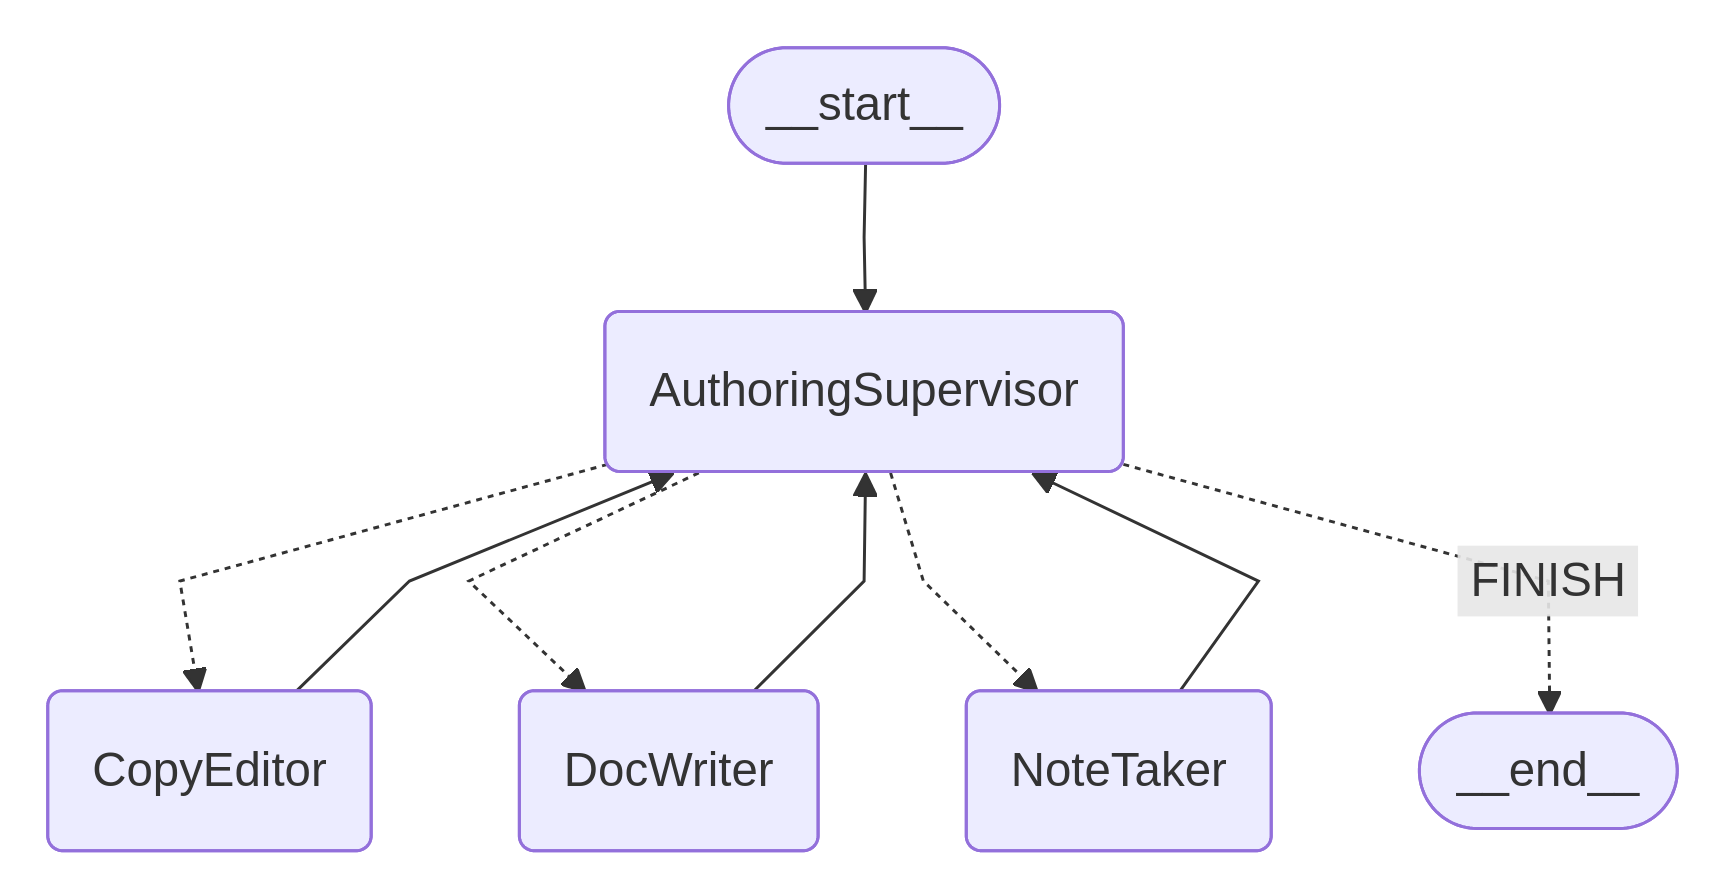

In [40]:
from IPython.display import Image, display

display(
    Image(
        compiled_authoring_graph.get_graph().draw_mermaid_png(
            curve_style=CurveStyle.LINEAR,
            node_colors=NodeStyles(first="#ffdfba", last="#baffc9", default="#fad7de"),
            wrap_label_n_words=9,
            output_file_path=None,
            draw_method=MermaidDrawMethod.PYPPETEER,
            background_color="white",
            padding=10,
        )
    )
)

In [41]:
def enter_authoring_chain(message: str, members: List[str]):
    results = {
        "messages": [HumanMessage(content=message)],
        "team_members": ", ".join(members),
    }
    return results

authoring_chain = (
    functools.partial(enter_authoring_chain, members=authoring_graph.nodes)
    | compiled_authoring_graph
)

In [42]:
for s in authoring_chain.stream(
    "What are the most common use-cases in this data. What are the most common domains?",
    {"recursion_limit": 100},
):
    if "__end__" not in s:
        print(s)
        print("---")

{'AuthoringSupervisor': {'next': 'DocWriter'}}
---
{'DocWriter': {'messages': [HumanMessage(content='As an AI trained in customer assistance, I can share that common use cases often span the following domains:\n\n1. **E-commerce**: Customers frequently inquire about product availability, return policies, shipping information, and order tracking.\n\n2. **Travel and Hospitality**: Customers seek assistance with booking flights, hotel reservations, cancellation policies, and itinerary changes.\n\n3. **Telecommunications**: Common inquiries involve account management, billing issues, service outages, and plan upgrades.\n\n4. **Financial Services**: Clients often request help with account access, transaction issues, loan inquiries, and investment advice.\n\n5. **Healthcare**: Patients typically need assistance with appointment scheduling, insurance claims, and medication inquiries.\n\n6. **Tech Support**: Users frequently require help with troubleshooting hardware/software issues, account s

In [43]:
from langchain_core.messages import AIMessage, BaseMessage, HumanMessage
from langchain_openai.chat_models import ChatOpenAI

super_llm = ChatOpenAI(model="gpt-4o-mini")

super_supervisor_agent = create_team_supervisor(
    super_llm,
    "You are a supervisor tasked with managing a conversation between the"
    " following teams: {team_members}. Given the following user request,"
    " respond with the worker to act next. Each worker will perform a"
    " task and respond with their results and status. When all workers are finished,"
    " you must respond with FINISH.",
    ["Research team", "Response team"],
)

In [44]:
class State(TypedDict):
    messages: Annotated[List[BaseMessage], operator.add]
    next: str

def get_last_message(state: State) -> str:
    return state["messages"][-1].content

def join_graph(response: dict):
    return {"messages": [response["messages"][-1]]}

In [45]:
super_graph = StateGraph(State)

super_graph.add_node("Research team", get_last_message | research_chain | join_graph)
super_graph.add_node("Response team", get_last_message | authoring_chain | join_graph)
super_graph.add_node("SuperSupervisor", super_supervisor_agent)

In [46]:
super_graph.add_edge("Research team", "SuperSupervisor")
super_graph.add_edge("Response team", "SuperSupervisor")
super_graph.add_conditional_edges(
    "SuperSupervisor",
    lambda x: x["next"],
    {
        "Response team": "Response team",
        "Research team": "Research team",
        "FINISH": END,
    },
)
super_graph.set_entry_point("SuperSupervisor")

In [47]:
compiled_super_graph = super_graph.compile()

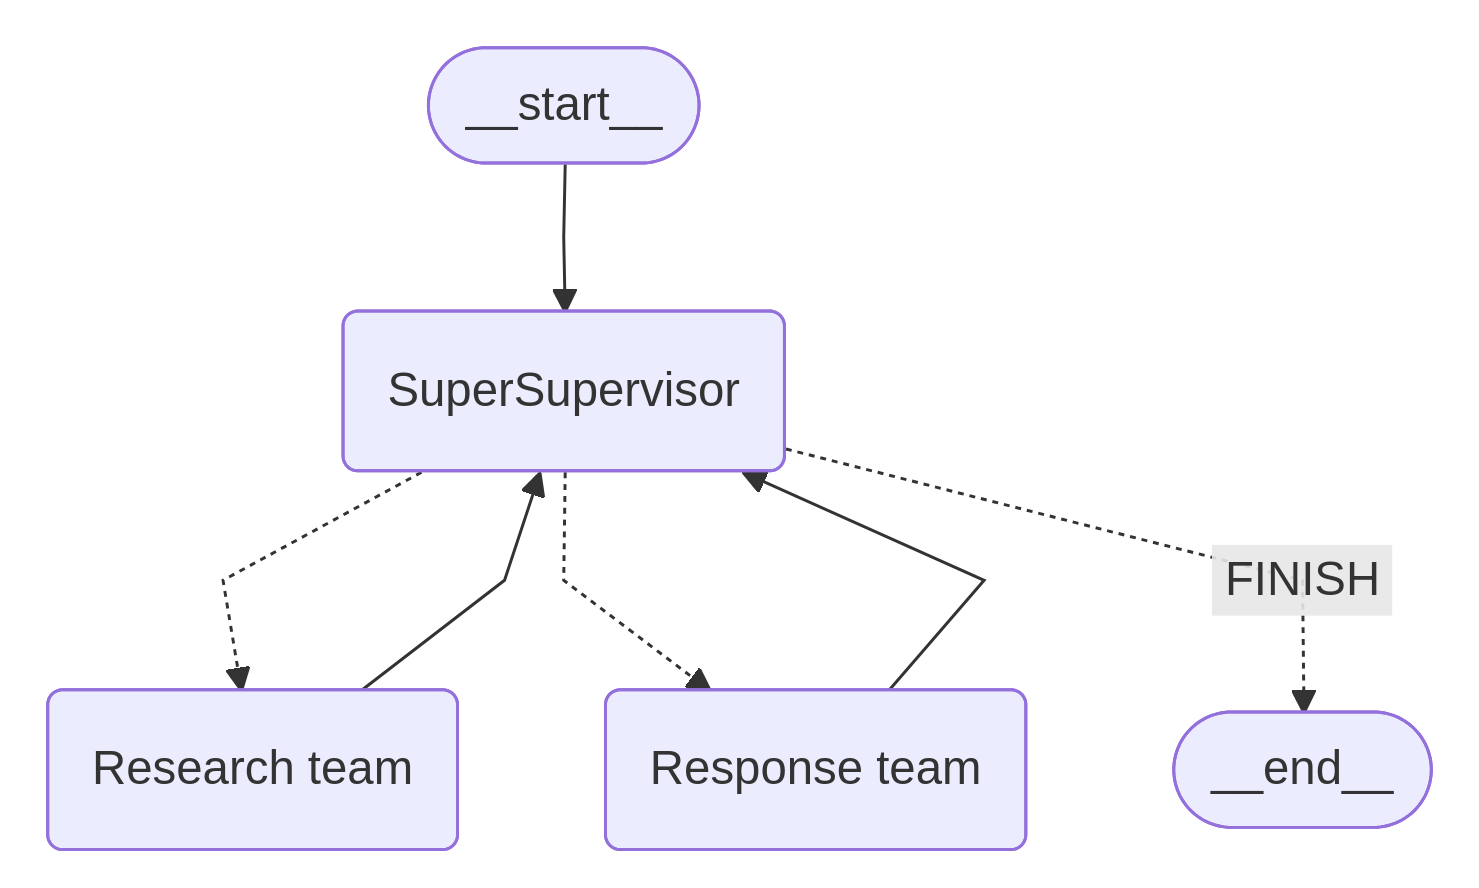

In [48]:
from IPython.display import Image, display

display(
    Image(
        compiled_super_graph.get_graph().draw_mermaid_png(
            curve_style=CurveStyle.LINEAR,
            node_colors=NodeStyles(first="#ffdfba", last="#baffc9", default="#fad7de"),
            wrap_label_n_words=9,
            output_file_path=None,
            draw_method=MermaidDrawMethod.PYPPETEER,
            background_color="white",
            padding=10,
        )
    )
)

In [49]:
WORKING_DIRECTORY = Path(create_random_subdirectory())

for s in compiled_super_graph.stream(
    {
        "messages": [
            HumanMessage(
                content="Write a report on the rise of context engineering in the LLM Space in 2025, and how it's impacting how people are using AI."
            )
        ],
    },
    {"recursion_limit": 30},
):
    if "__end__" not in s:
        print(s)
        print("---")

{'SuperSupervisor': {'next': 'Research team'}}
---
{'Research team': {'messages': [HumanMessage(content="### Report on the Rise of Context Engineering in the LLM Space in 2025\n\n#### Introduction\nAs we progress through 2025, the landscape of artificial intelligence (AI) is increasingly dominated by the concept of context engineering within large language models (LLMs). This fundamental shift represents a maturation in our understanding of how context influences AI's ability to operate effectively, leading to improvements in human-AI interactions. This report provides an overview of context engineering, its emergence in the LLM sector, and its implications for AI applications across various domains.\n\n#### Definition of Context Engineering\nContext engineering involves designing interactions and data environments to optimize how AI models interpret and respond to inputs. Unlike traditional programming methods which rely on fixed rules, LLMs utilize probabilistic models that adapt bas